# Knowledge Graphs and Semantic Technologies -- SHACL Tutorial

In this tutorial you will learn to work with SHACL (Shapes Constraint Language), a language for validating graphs. You will be creating your own SHACL shapes. This can be done using https://shacl.org/playground/, Protege, or other applications. In this tutorial we will use **GraphDB** for loading our shapes for data validation.

## Getting started

Create a new repository in **GraphDB** and enable the 'Support SHACL validation' option. Make sure to check the ‘log validation violations’ as well, to produce violation reports.

e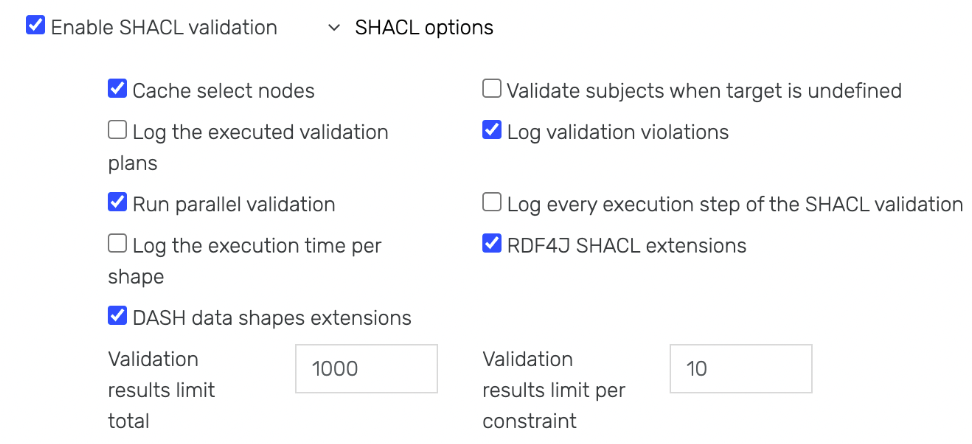

## Adding constraints

Go to Import ‣ User data ‣ Import RDF text snippet, and
add the following cardinality constraint:

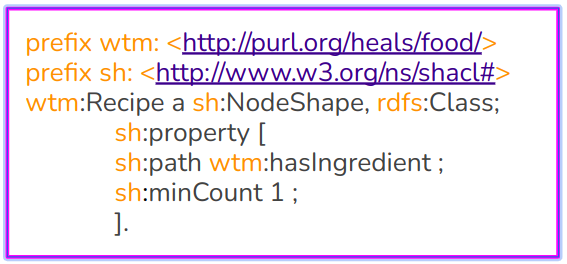

In the dialog that opens, select Target graphs ‣ Named graph.


And use http://rdf4j.org/schema/rdf4j#SHACLShapeGraph

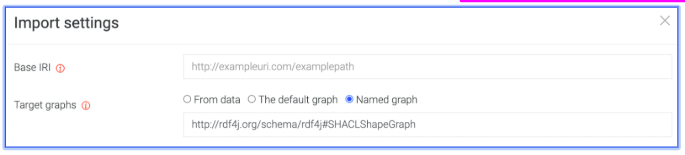

Load ingredients.rdf, recipes.rdf, and failing_recipe.nt into GraphDB. Did they load correctly?

## Validation reports

You should see a validation report appear when loading the failing_recipe.nt file:

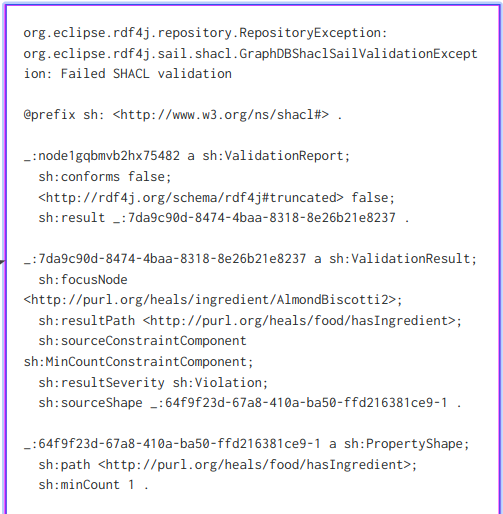

Validation reports are logged to /Logs in the GraphDB home directory

On Mac: ~/Library/Application Support/GraphDB.

On Windows: \Users\<username>\AppData\Roaming\GraphDB.


On Linux and other Unixes: ~/.graphdb.


## Exercises - SHACL constraints

1. Add a value range (sh:minInclusive, sh:minExclusive, sh:maxInclusive) constraint that would validate/invalidate your graph. Example: add ranges for the property wtm:hasCookingTemperature.


In [2]:
print("Value range added:")
print("""
@prefix sh: <http://www.w3.org/ns/shacl#> .
@prefix wtm: <http://purl.org/heals/food/> .
@prefix xsd: <http://www.w3.org/2001/XMLSchema#> .

wtm:CookingTemperatureShape a sh:NodeShape ;
  sh:targetSubjectsOf wtm:hasCookingTemperature ;
  sh:property [
    sh:path wtm:hasCookingTemperature ;
    sh:datatype xsd:decimal ;
    sh:minInclusive 0 ;
    sh:maxInclusive 300 ;
    sh:message "Cooking temperature must be between 0 and 300." ;
  ] .
""")

Value range added:

@prefix sh: <http://www.w3.org/ns/shacl#> .
@prefix wtm: <http://purl.org/heals/food/> .
@prefix xsd: <http://www.w3.org/2001/XMLSchema#> .

wtm:CookingTemperatureShape a sh:NodeShape ;
  sh:targetSubjectsOf wtm:hasCookingTemperature ;
  sh:property [
    sh:path wtm:hasCookingTemperature ;
    sh:datatype xsd:decimal ;
    sh:minInclusive 0 ;
    sh:maxInclusive 300 ;
    sh:message "Cooking temperature must be between 0 and 300." ;
  ] .



2. Add a property pair constraint (sh:equals, sh:disjoint, sh:lessThan, sh:lessThanOrEquals) that would validate/invalidate your graph.

In [1]:
print("Property pair: sh:hasMinTemperature must be strictly less than sh:hasMaxTemperature")
print("""

@prefix sh: <http://www.w3.org/ns/shacl#> .
@prefix wtm: <http://purl.org/heals/food/> .
@prefix xsd: <http://www.w3.org/2001/XMLSchema#> .

wtm:TemperatureRangeShape a sh:NodeShape ;
  sh:targetSubjectsOf wtm:hasMinTemperature ;
  sh:property [
    sh:path wtm:hasMinTemperature ;
    sh:datatype xsd:decimal ;
    sh:lessThan wtm:hasMaxTemperature ;
    sh:message "Minimum temperature must be less than maximum temperature." ;
  ] .""")

Property pair: sh:hasMinTemperature must be strictly less than sh:hasMaxTemperature


@prefix sh: <http://www.w3.org/ns/shacl#> .
@prefix wtm: <http://purl.org/heals/food/> .
@prefix xsd: <http://www.w3.org/2001/XMLSchema#> .

wtm:TemperatureRangeShape a sh:NodeShape ;
  sh:targetSubjectsOf wtm:hasMinTemperature ;
  sh:property [
    sh:path wtm:hasMinTemperature ;
    sh:datatype xsd:decimal ;
    sh:lessThan wtm:hasMaxTemperature ;
    sh:message "Minimum temperature must be less than maximum temperature." ;
  ] .


## Exercises - advanced: SHACL rules

Try to write up the following SHACL SPARQLrule:


IF the cooktime of a dessert (wtm:isRecommendedForCourse Dessert) is shorter than 35 minutes, THEN the recipe will get the attribute :quickDessertRecipe "True"^^xsd:boolean

**GraphDB** doesn’t offer support for SHACL rules, but you can try to apply your rule to your data using SHACL Play! https://shacl-play.sparna.fr/play/convert

In [3]:
print('''
@prefix sh: <http://www.w3.org/ns/shacl#> .
@prefix wtm: <http://purl.org/heals/food/> .
@prefix xsd: <http://www.w3.org/2001/XMLSchema#> .
@prefix : <http://purl.org/heals/food/> .

wtm:QuickDessertShape a sh:NodeShape ;
  sh:targetClass wtm:Recipe ;
  sh:rule [
    a sh:SPARQLRule ;
    sh:construct """
      CONSTRUCT {
        ?this :quickDessertRecipe "true"^^xsd:boolean .
      }
      WHERE {
        ?this wtm:isRecommendedForCourse wtm:Dessert .
        ?this wtm:hasCookTime ?cooktime .
        FILTER (?cooktime < 35)
      }
    """ ;
  ] .''')


@prefix sh: <http://www.w3.org/ns/shacl#> .
@prefix wtm: <http://purl.org/heals/food/> .
@prefix xsd: <http://www.w3.org/2001/XMLSchema#> .
@prefix : <http://purl.org/heals/food/> .

wtm:QuickDessertShape a sh:NodeShape ;
  sh:targetClass wtm:Recipe ;
  sh:rule [
    a sh:SPARQLRule ;
    sh:construct """
      CONSTRUCT {
        ?this :quickDessertRecipe "true"^^xsd:boolean .
      }
      WHERE {
        ?this wtm:isRecommendedForCourse wtm:Dessert .
        ?this wtm:hasCookTime ?cooktime .
        FILTER (?cooktime < 35)
      }
    """ ;
  ] .
